# VNM Stock EDA
**Dataset:** VNM_2225.csv — Vinamilk (VNM) on HOSE, Oct 2021 – Jun 2025  
**Sections:** Data Quality → Price & Trend → Returns → Volatility → Volume → Indicators → Market Context → Calendar

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})
BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'
GREEN  = '#2ca02c'
RED    = '#d62728'
GRAY   = '#7f7f7f'

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv('VNM_2225.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (913, 43)


,date,open,high,low,close,volume,sma_10,sma_20,ema_20,macd_histogram,...,volume_sma_20,volume_ratio,volume_change,price_volume,vnindex,vnindex_volume,vnindex_return,correlation_market_20,beta_20,day_of_week
0,2021-10-29,70.98,71.29,70.75,71.06,3748500,NaN,NaN,71.060000,0.000000,...,NaN,NaN,NaN,266368410.0,1444.27,904699600,NaN,NaN,NaN,4
1,2021-11-01,71.14,71.53,70.35,70.51,5083800,NaN,NaN,71.007619,-0.035100,...,NaN,NaN,0.356222,358458738.0,1438.97,1052909000,-0.003670,NaN,NaN,0
2,2021-11-02,70.51,70.51,69.73,69.88,4888900,NaN,NaN,70.900227,-0.095385,...,NaN,NaN,-0.038337,341636332.0,1452.46,942151100,0.009375,NaN,NaN,1


---
## 1. Data Quality

In [5]:
# ── Basic info ─────────────────────────────────────────────────────────────
print('=== Date range ===')
print(f"From : {df['date'].min().date()}")
print(f"To   : {df['date'].max().date()}")
print(f"Rows : {len(df)}")

print('\n=== Missing values (%) ===')
miss = (df.isnull().sum() / len(df) * 100).round(2)
print(miss[miss > 0].to_string())

print('\n=== Duplicated rows ===')
print(df.duplicated().sum())

=== Date range ===
From : 2021-10-29
To   : 2025-06-30
Rows : 913

=== Missing values (%) ===
sma_10                      0.99
sma_20                      2.08
rsi_14                      1.42
cci_14                      1.42
momentum_10                 1.10
roc_12                      1.31
log_return                  0.11
atr_14                      1.42
rolling_std_20              2.08
historical_volatility_20    2.19
return_lag_1                0.22
return_lag_2                0.33
return_lag_3                0.44
return_lag_4                0.55
return_lag_5                0.66
rolling_max_20              2.08
rolling_min_20              2.08
rolling_mean_20             2.08
distance_from_high_20       2.08
distance_from_low_20        2.08
volume_sma_20               2.08
volume_ratio                2.08
volume_change               0.11
vnindex_return              0.11
correlation_market_20       2.19
beta_20                     2.19

=== Duplicated rows ===
0


In [6]:
# ── OHLCV sanity checks ────────────────────────────────────────────────────
checks = {
    'high >= low'       : (df['high'] >= df['low']).all(),
    'high >= open'      : (df['high'] >= df['open']).all(),
    'high >= close'     : (df['high'] >= df['close']).all(),
    'low  <= open'      : (df['low']  <= df['open']).all(),
    'low  <= close'     : (df['low']  <= df['close']).all(),
    'volume > 0'        : (df['volume'] > 0).all(),
}
for k, v in checks.items():
    print(f"  {'✅' if v else '❌'}  {k}")

  ✅  high >= low
  ✅  high >= open
  ✅  high >= close
  ✅  low  <= open
  ✅  low  <= close
  ✅  volume > 0


Gaps > 5 calendar days: 7
  2022-01-28 → 2022-02-07  (10 days)
  2023-01-19 → 2023-01-27  (8 days)
  2023-04-28 → 2023-05-04  (6 days)
  2024-02-07 → 2024-02-15  (8 days)
  2024-04-26 → 2024-05-02  (6 days)
  2025-01-24 → 2025-02-03  (10 days)
  2025-04-29 → 2025-05-05  (6 days)


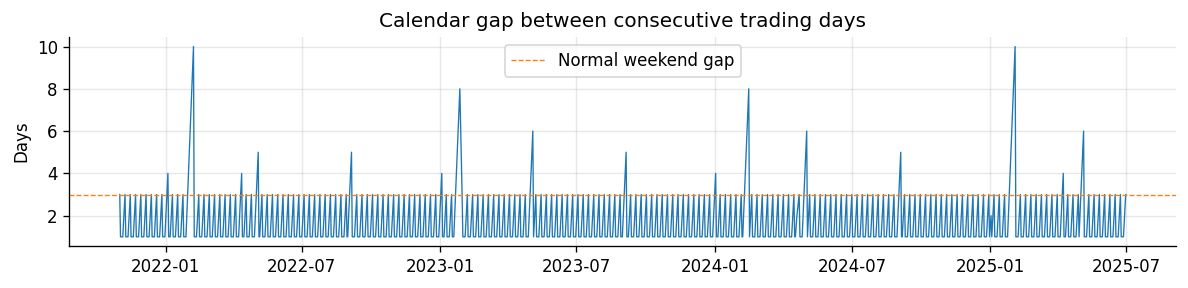

In [7]:
# ── Date gaps ──────────────────────────────────────────────────────────────
date_diff = df['date'].diff().dt.days.dropna()
large_gaps = date_diff[date_diff > 5]
print(f'Gaps > 5 calendar days: {len(large_gaps)}')
if len(large_gaps):
    for idx in large_gaps.index:
        print(f"  {df.loc[idx-1,'date'].date()} → {df.loc[idx,'date'].date()}  ({int(large_gaps[idx])} days)")

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(df['date'], date_diff.reindex(df.index), color=BLUE, lw=0.8)
ax.axhline(3, color=ORANGE, ls='--', lw=0.8, label='Normal weekend gap')
ax.set_title('Calendar gap between consecutive trading days')
ax.set_ylabel('Days')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# ── Descriptive statistics ─────────────────────────────────────────────────
df[['open','high','low','close','volume','log_return','historical_volatility_20']].describe().round(4)

,open,high,low,close,volume,log_return,historical_volatility_20
count,913.0000,913.0000,913.0000,913.0000,9.130000e+02,912.0000,893.0000
mean,60.9050,61.4448,60.3874,60.8387,2.926879e+06,-0.0003,0.2055
std,4.1918,4.2035,4.1442,4.1972,1.947992e+06,0.0138,0.0861
min,47.4200,50.9200,47.4200,47.9700,4.478840e+05,-0.0708,0.0701
25%,58.3800,58.8600,57.8800,58.2700,1.672065e+06,-0.0076,0.1494
50%,60.4000,60.7400,59.8100,60.2300,2.505912e+06,-0.0012,0.1881
75%,63.9200,64.6100,63.4200,63.9500,3.525626e+06,0.0059,0.2324
max,71.2900,71.5300,70.7500,71.1400,2.116741e+07,0.0669,0.5205


---
## 2. Price & Trend

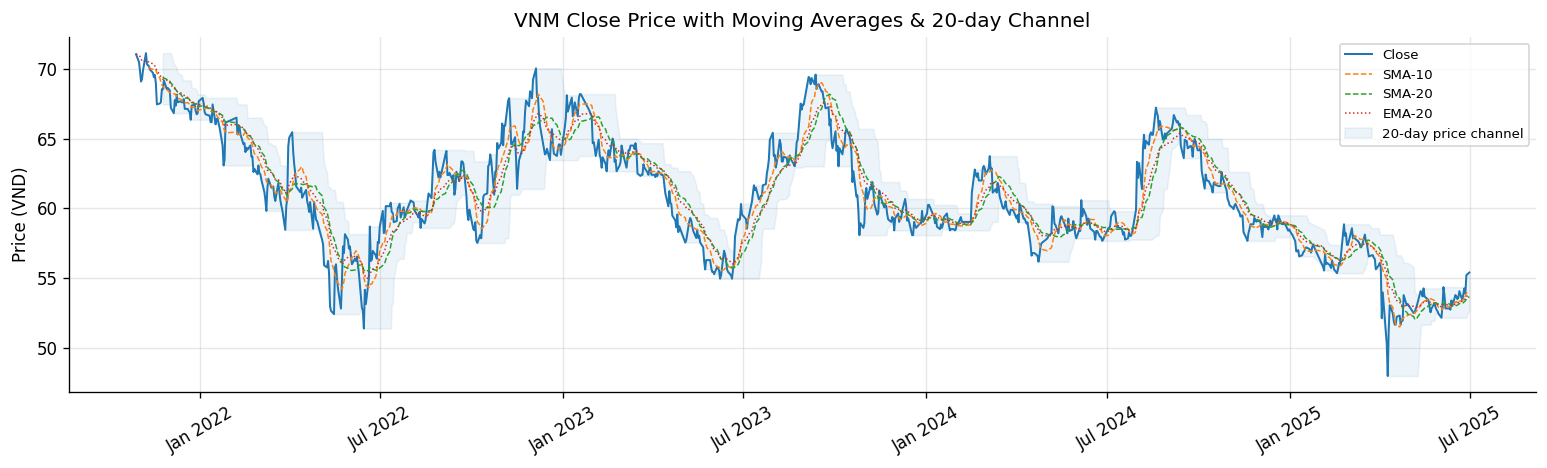

In [9]:
# ── Close price with moving averages ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['close'],   color=BLUE,   lw=1.2, label='Close')
ax.plot(df['date'], df['sma_10'],  color=ORANGE,  lw=0.9, ls='--', label='SMA-10')
ax.plot(df['date'], df['sma_20'],  color=GREEN,   lw=0.9, ls='--', label='SMA-20')
ax.plot(df['date'], df['ema_20'],  color=RED,     lw=0.9, ls=':',  label='EMA-20')
ax.fill_between(df['date'], df['rolling_min_20'], df['rolling_max_20'],
                alpha=0.08, color=BLUE, label='20-day price channel')
ax.set_title('VNM Close Price with Moving Averages & 20-day Channel')
ax.set_ylabel('Price (VND)')
ax.legend(loc='upper right', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

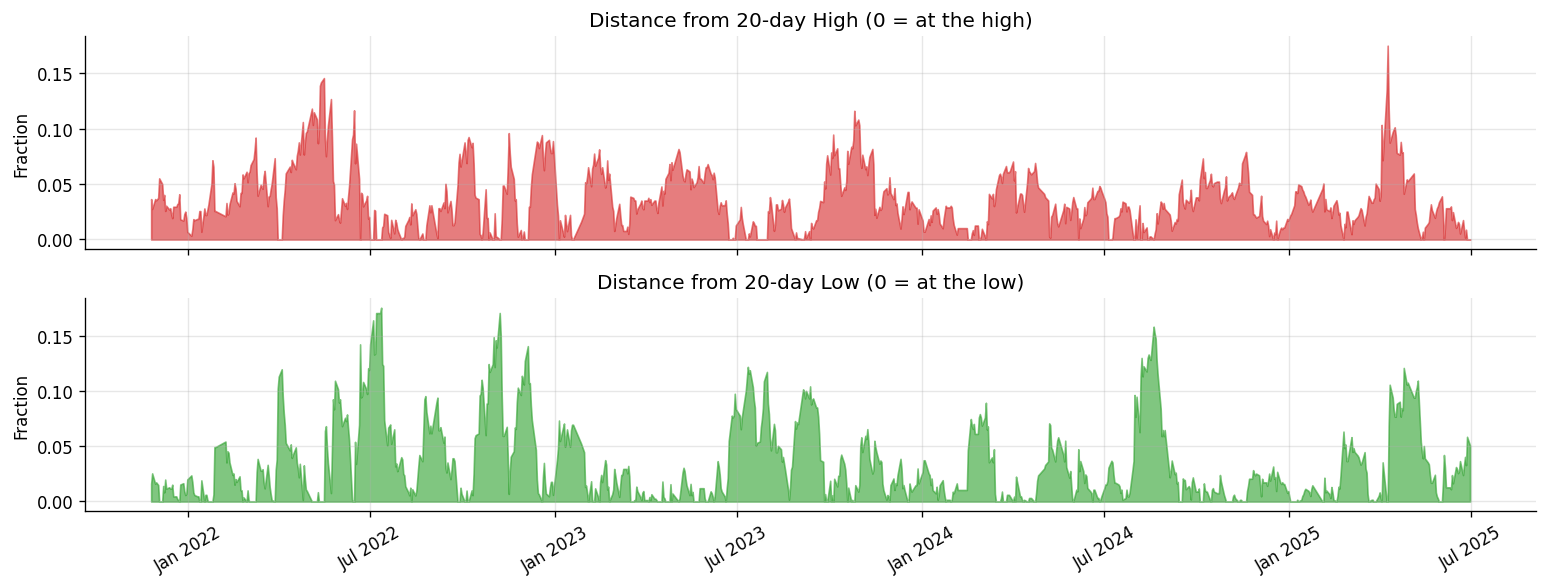

In [10]:
# ── Distance from 20-day high/low ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].fill_between(df['date'], df['distance_from_high_20'], alpha=0.6, color=RED)
axes[0].set_title('Distance from 20-day High (0 = at the high)')
axes[0].set_ylabel('Fraction')

axes[1].fill_between(df['date'], df['distance_from_low_20'], alpha=0.6, color=GREEN)
axes[1].set_title('Distance from 20-day Low (0 = at the low)')
axes[1].set_ylabel('Fraction')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 3. Returns Analysis

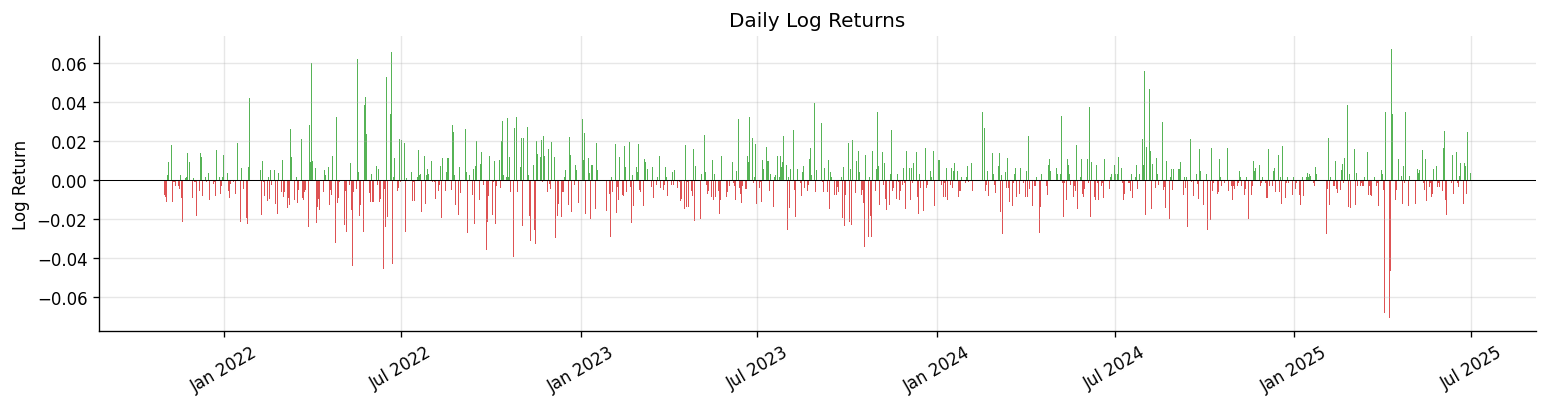

In [11]:
# ── Log return over time ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
colors = [GREEN if r >= 0 else RED for r in df['log_return'].fillna(0)]
ax.bar(df['date'], df['log_return'], color=colors, width=1, alpha=0.8)
ax.axhline(0, color='black', lw=0.6)
ax.set_title('Daily Log Returns')
ax.set_ylabel('Log Return')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

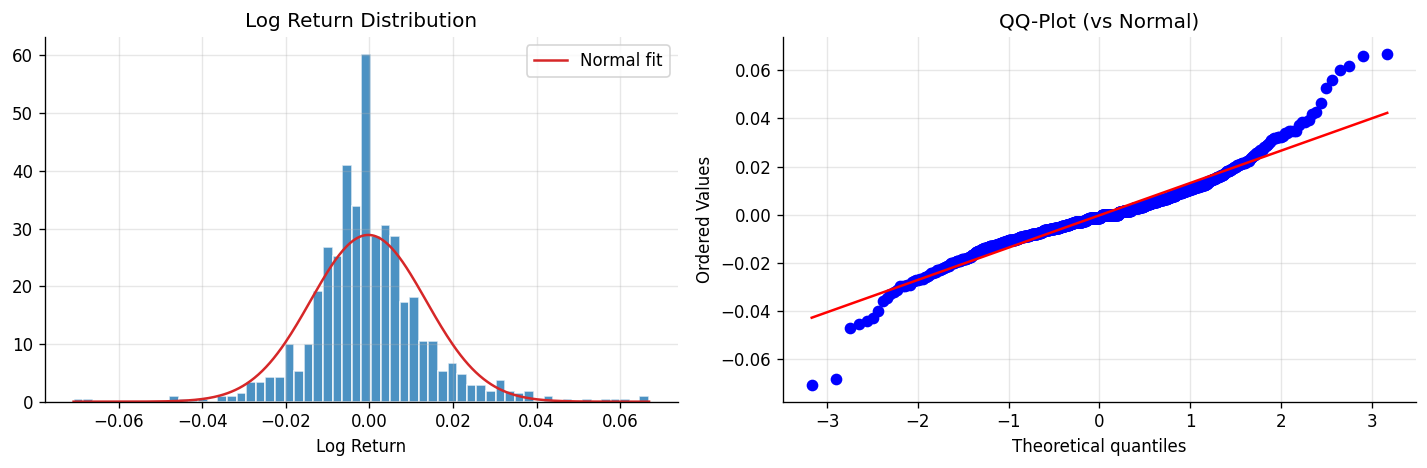

Skewness : 0.4253
Kurtosis : 4.0271  (excess; normal=0)
Std dev  : 0.0138


In [12]:
# ── Return distribution ────────────────────────────────────────────────────
from scipy import stats as sp_stats

ret = df['log_return'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(ret, bins=60, color=BLUE, edgecolor='white', alpha=0.8, density=True)
x = np.linspace(ret.min(), ret.max(), 300)
axes[0].plot(x, sp_stats.norm.pdf(x, ret.mean(), ret.std()),
             color=RED, lw=1.5, label='Normal fit')
axes[0].set_title('Log Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].legend()

# QQ-plot
sp_stats.probplot(ret, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot (vs Normal)')

plt.tight_layout()
plt.show()

print(f'Skewness : {ret.skew():.4f}')
print(f'Kurtosis : {ret.kurtosis():.4f}  (excess; normal=0)')
print(f'Std dev  : {ret.std():.4f}')

In [13]:
# ── Stationarity (ADF test) ────────────────────────────────────────────────
for col, label in [('close', 'Close Price'), ('log_return', 'Log Return')]:
    series = df[col].dropna()
    adf_stat, p_val, *_ = adfuller(series)
    result = '✅ Stationary' if p_val < 0.05 else '❌ Non-stationary'
    print(f'{label:20s} | ADF={adf_stat:7.3f} | p={p_val:.4f} | {result}')

Close Price          | ADF= -3.146 | p=0.0234 | ✅ Stationary
Log Return           | ADF=-32.217 | p=0.0000 | ✅ Stationary


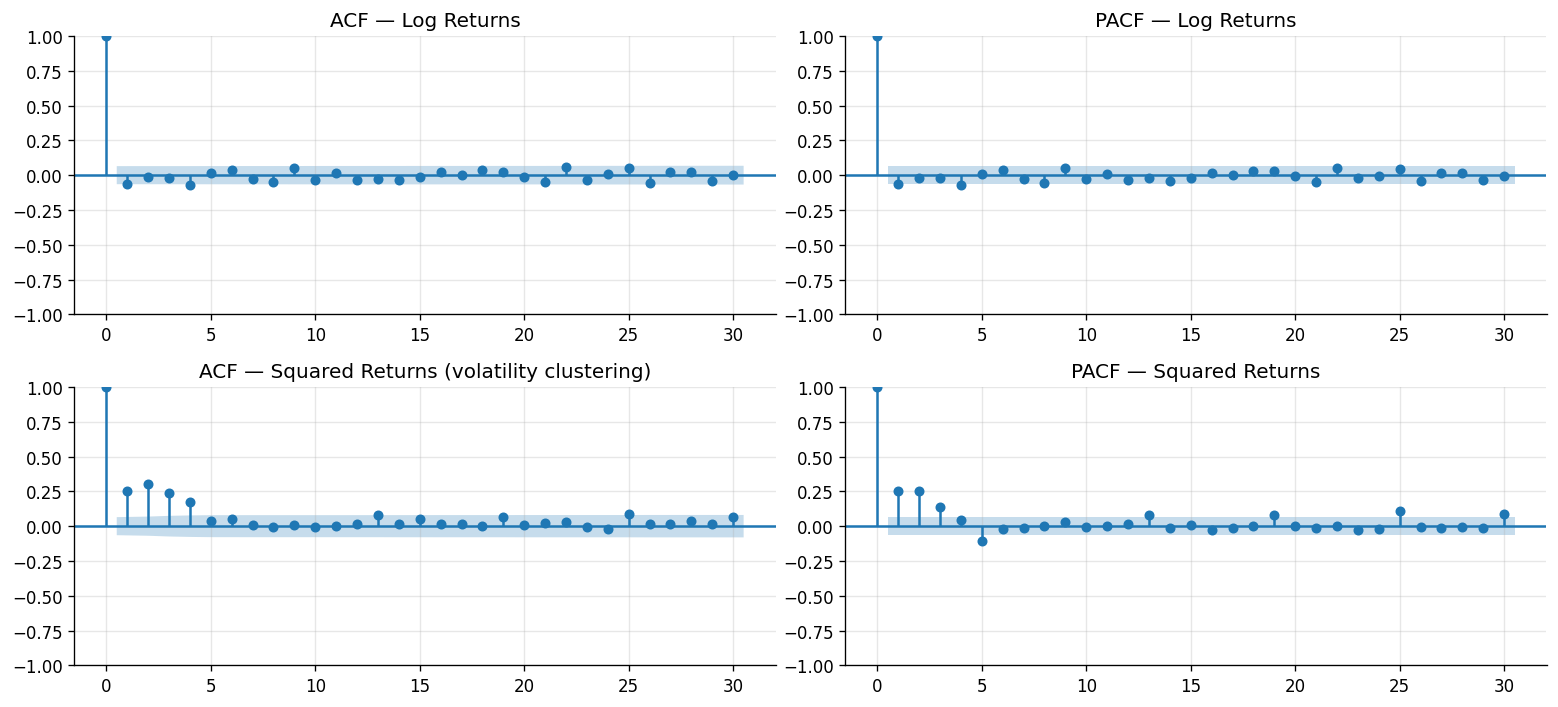

In [14]:
# ── ACF / PACF of log returns ──────────────────────────────────────────────
ret = df['log_return'].dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

plot_acf (ret,    lags=30, ax=axes[0,0], title='ACF — Log Returns')
plot_pacf(ret,    lags=30, ax=axes[0,1], title='PACF — Log Returns')
plot_acf (ret**2, lags=30, ax=axes[1,0], title='ACF — Squared Returns (volatility clustering)')
plot_pacf(ret**2, lags=30, ax=axes[1,1], title='PACF — Squared Returns')

plt.tight_layout()
plt.show()

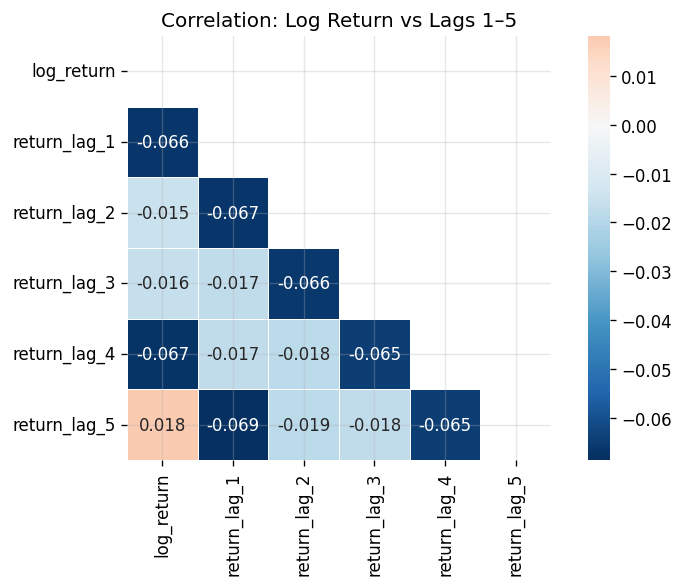

In [15]:
# ── Lagged return correlations ─────────────────────────────────────────────
lag_cols = ['log_return','return_lag_1','return_lag_2','return_lag_3','return_lag_4','return_lag_5']
corr = df[lag_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation: Log Return vs Lags 1–5')
plt.tight_layout()
plt.show()

---
## 4. Volatility Analysis

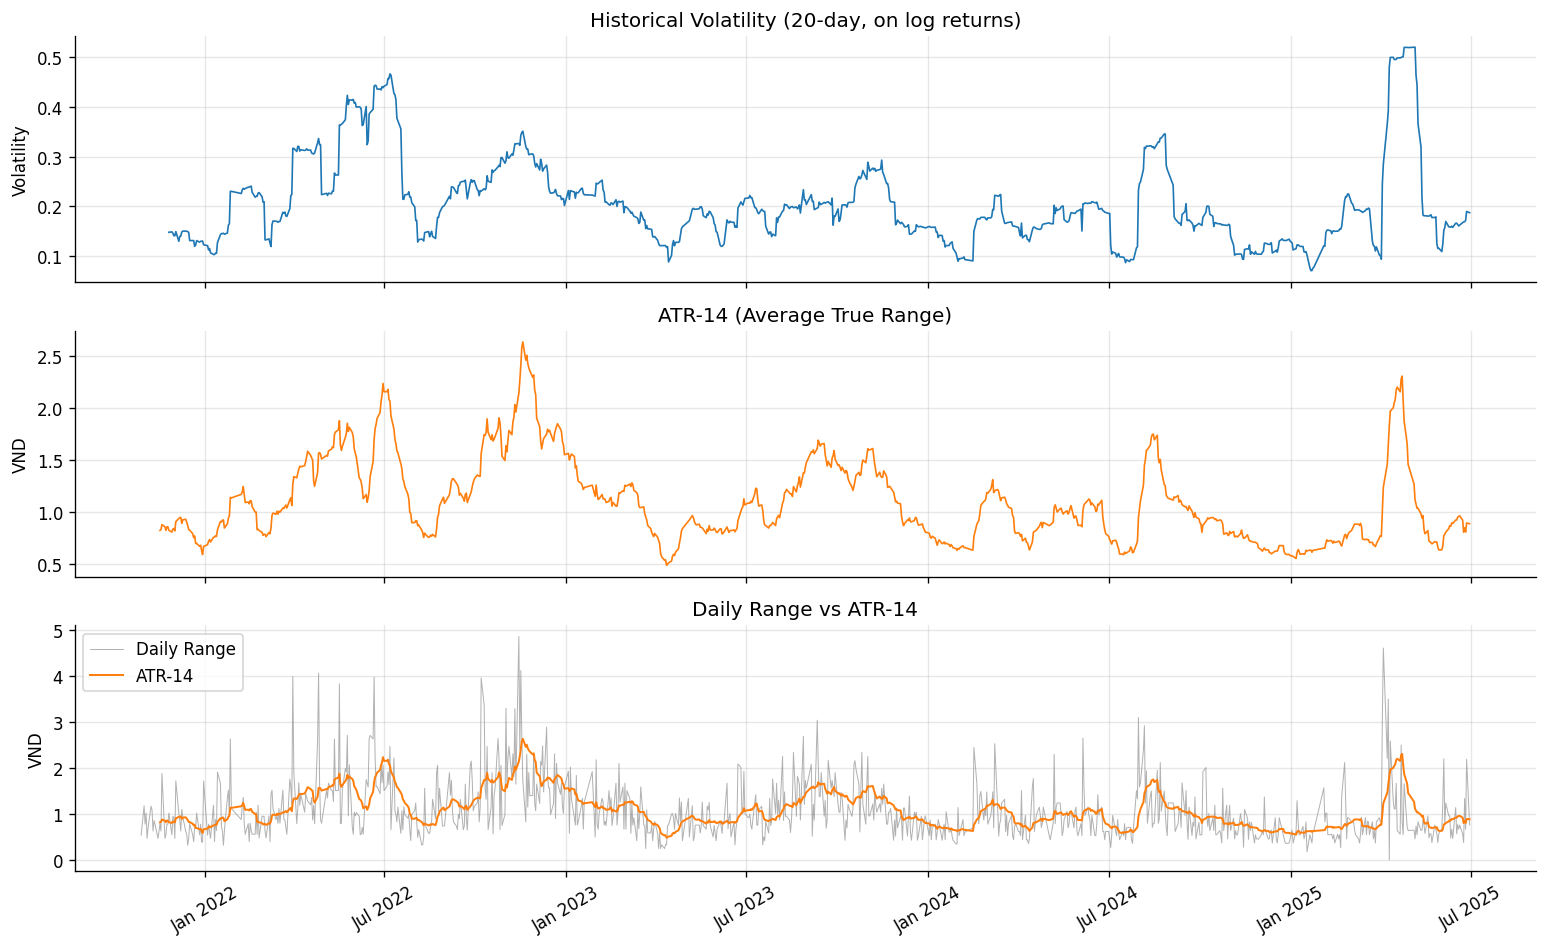

In [16]:
# ── Volatility measures over time ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df['date'], df['historical_volatility_20'], color=BLUE, lw=1)
axes[0].set_title('Historical Volatility (20-day, on log returns)')
axes[0].set_ylabel('Volatility')

axes[1].plot(df['date'], df['atr_14'], color=ORANGE, lw=1)
axes[1].set_title('ATR-14 (Average True Range)')
axes[1].set_ylabel('VND')

axes[2].plot(df['date'], df['daily_range'], color=GRAY,   lw=0.6, alpha=0.6, label='Daily Range')
axes[2].plot(df['date'], df['atr_14'],      color=ORANGE, lw=1.2, label='ATR-14')
axes[2].set_title('Daily Range vs ATR-14')
axes[2].set_ylabel('VND')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

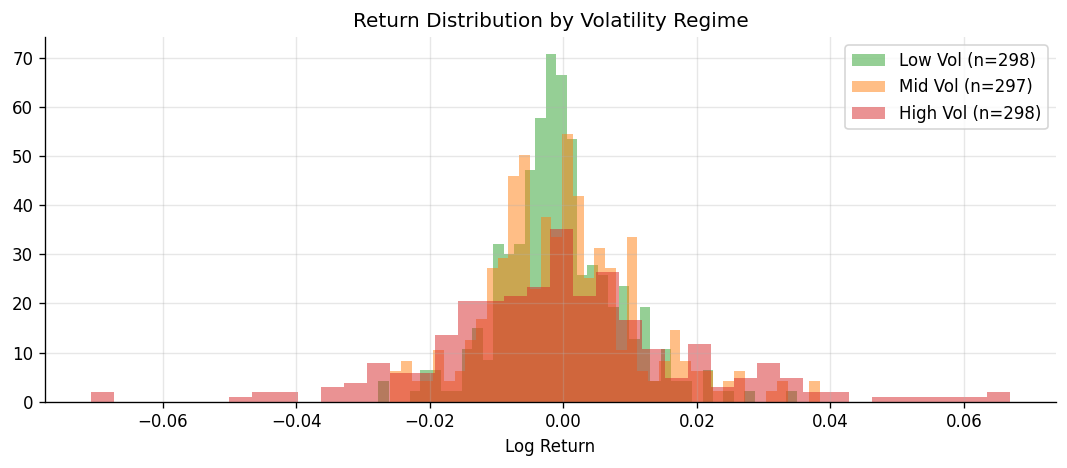

              mean     std     min     max
vol_regime                                
Low Vol    -0.0005  0.0087 -0.0277  0.0350
Mid Vol    -0.0002  0.0112 -0.0260  0.0384
High Vol    0.0000  0.0194 -0.0708  0.0669


In [17]:
# ── Return distribution by volatility regime ───────────────────────────────
df['vol_regime'] = pd.qcut(df['historical_volatility_20'], q=3,
                            labels=['Low Vol', 'Mid Vol', 'High Vol'])

fig, ax = plt.subplots(figsize=(9, 4))
for regime, color in zip(['Low Vol','Mid Vol','High Vol'], [GREEN, ORANGE, RED]):
    subset = df[df['vol_regime'] == regime]['log_return'].dropna()
    ax.hist(subset, bins=40, alpha=0.5, color=color, density=True, label=f'{regime} (n={len(subset)})')
ax.set_title('Return Distribution by Volatility Regime')
ax.set_xlabel('Log Return')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('vol_regime')['log_return'].agg(['mean','std','min','max']).round(4))

---
## 5. Volume Analysis

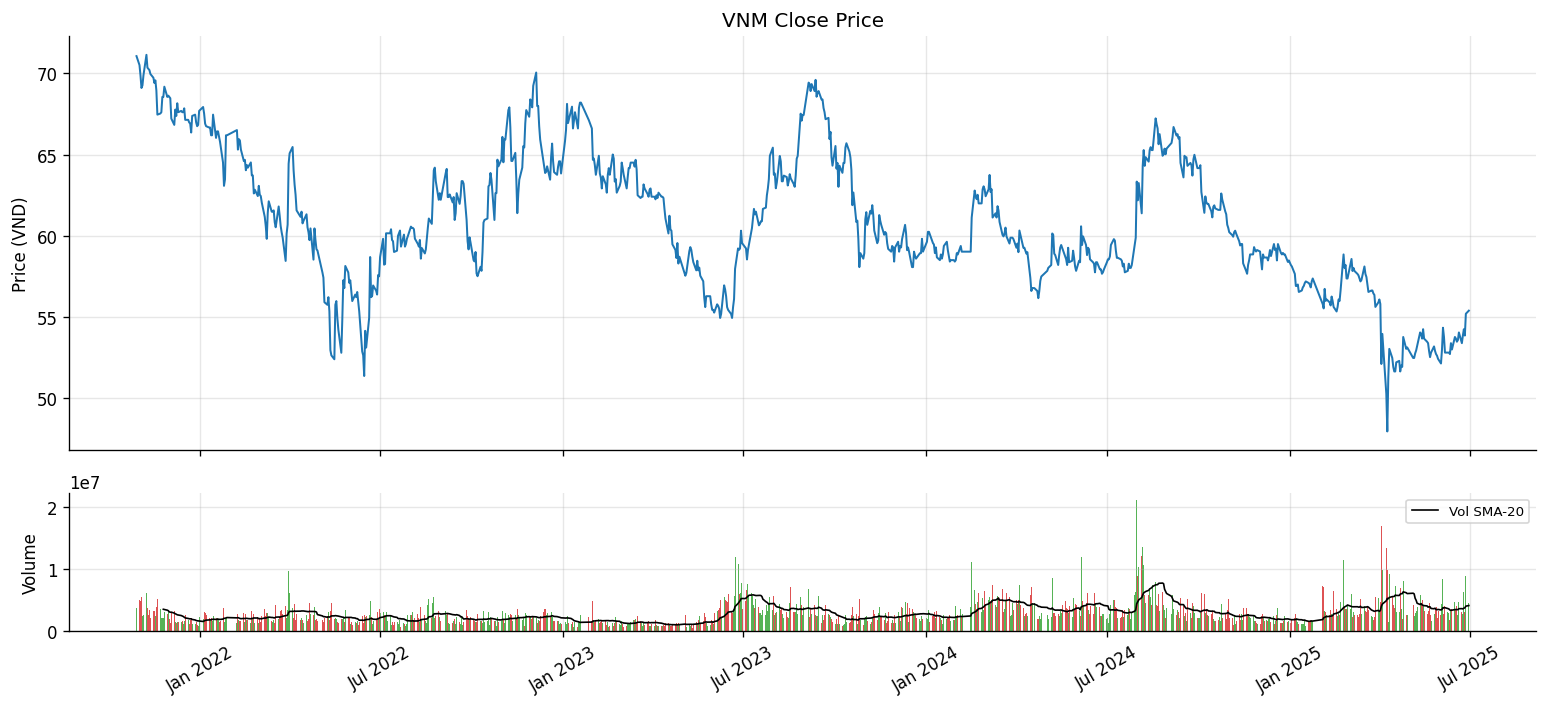

In [18]:
# ── Price + Volume chart ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(df['date'], df['close'], color=BLUE, lw=1.2)
ax1.set_title('VNM Close Price')
ax1.set_ylabel('Price (VND)')

vol_colors = [GREEN if r >= 0 else RED for r in df['log_return'].fillna(0)]
ax2.bar(df['date'], df['volume'], color=vol_colors, width=1, alpha=0.8)
ax2.plot(df['date'], df['volume_sma_20'], color='black', lw=1, label='Vol SMA-20')
ax2.set_ylabel('Volume')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

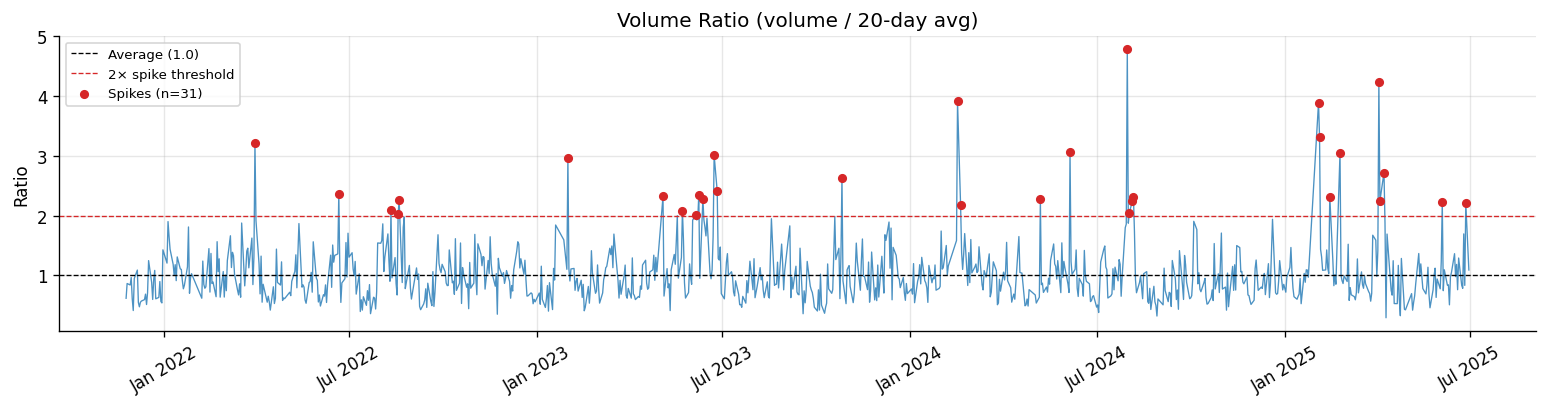

In [19]:
# ── Volume ratio over time + spikes ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df['date'], df['volume_ratio'], color=BLUE, lw=0.8, alpha=0.8)
ax.axhline(1.0, color='black',  lw=0.8, ls='--', label='Average (1.0)')
ax.axhline(2.0, color=RED,      lw=0.8, ls='--', label='2× spike threshold')
spikes = df[df['volume_ratio'] > 2]
ax.scatter(spikes['date'], spikes['volume_ratio'], color=RED, s=20, zorder=5, label=f'Spikes (n={len(spikes)})')
ax.set_title('Volume Ratio (volume / 20-day avg)')
ax.set_ylabel('Ratio')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

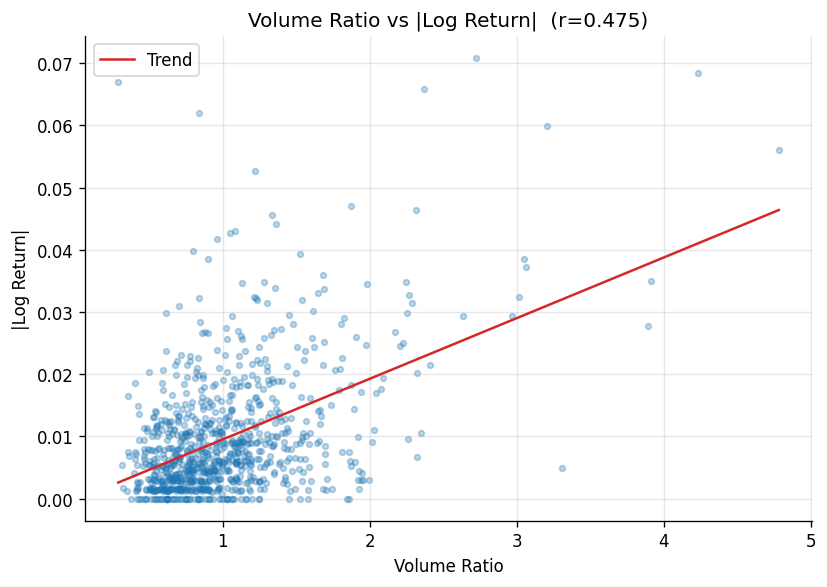

In [20]:
# ── Volume ratio vs absolute return scatter ────────────────────────────────
plot_df = df[['volume_ratio','log_return']].dropna().copy()
plot_df['abs_return'] = plot_df['log_return'].abs()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df['volume_ratio'], plot_df['abs_return'],
           alpha=0.3, s=12, color=BLUE)
# trend line
z = np.polyfit(plot_df['volume_ratio'], plot_df['abs_return'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df['volume_ratio'].min(), plot_df['volume_ratio'].max(), 100)
ax.plot(x_line, p(x_line), color=RED, lw=1.5, label='Trend')
corr_val = plot_df['volume_ratio'].corr(plot_df['abs_return'])
ax.set_title(f'Volume Ratio vs |Log Return|  (r={corr_val:.3f})')
ax.set_xlabel('Volume Ratio')
ax.set_ylabel('|Log Return|')
ax.legend()
plt.tight_layout()
plt.show()

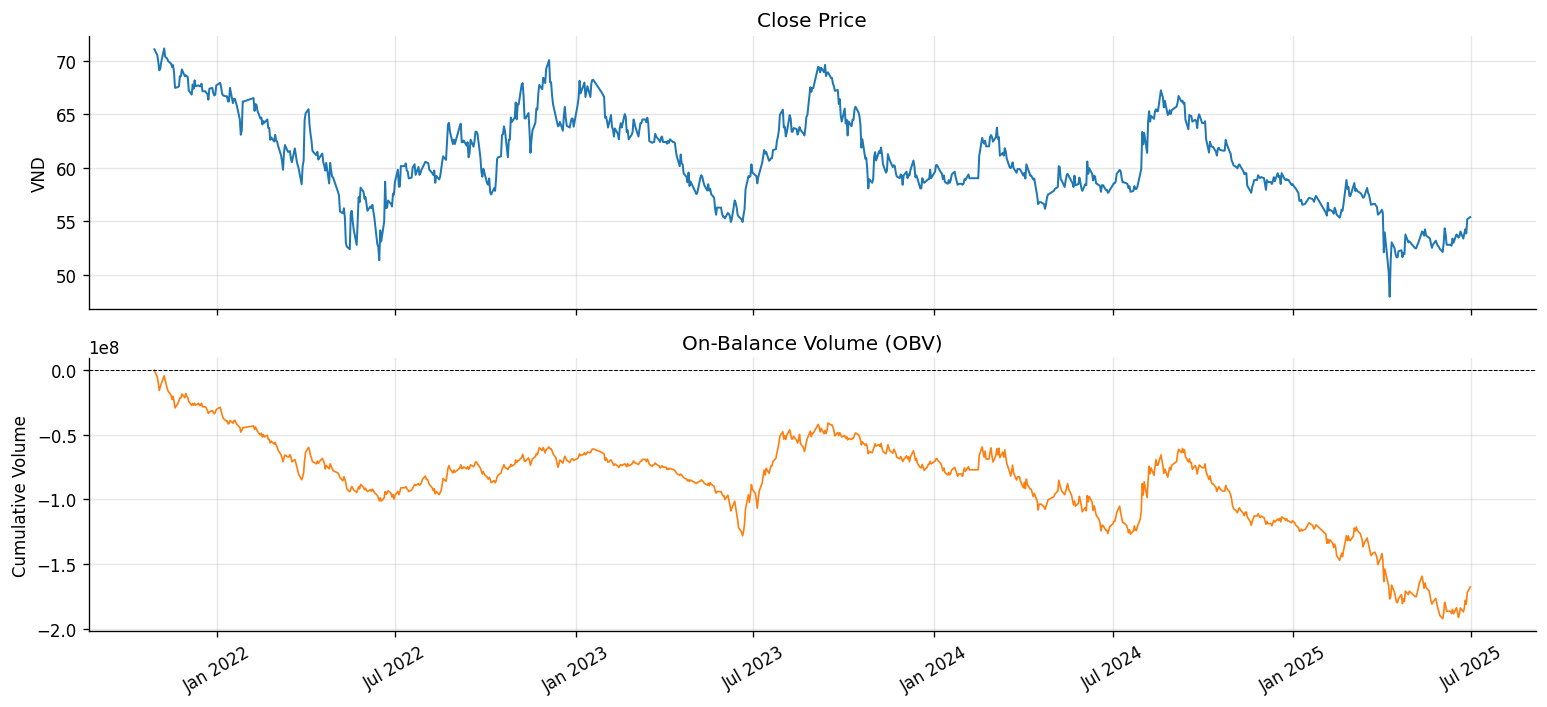

In [21]:
# ── OBV trend ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(df['date'], df['close'], color=BLUE, lw=1.2)
ax1.set_title('Close Price')
ax1.set_ylabel('VND')

ax2.plot(df['date'], df['obv'], color=ORANGE, lw=1)
ax2.axhline(0, color='black', lw=0.6, ls='--')
ax2.set_title('On-Balance Volume (OBV)')
ax2.set_ylabel('Cumulative Volume')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 6. Momentum & Technical Indicators

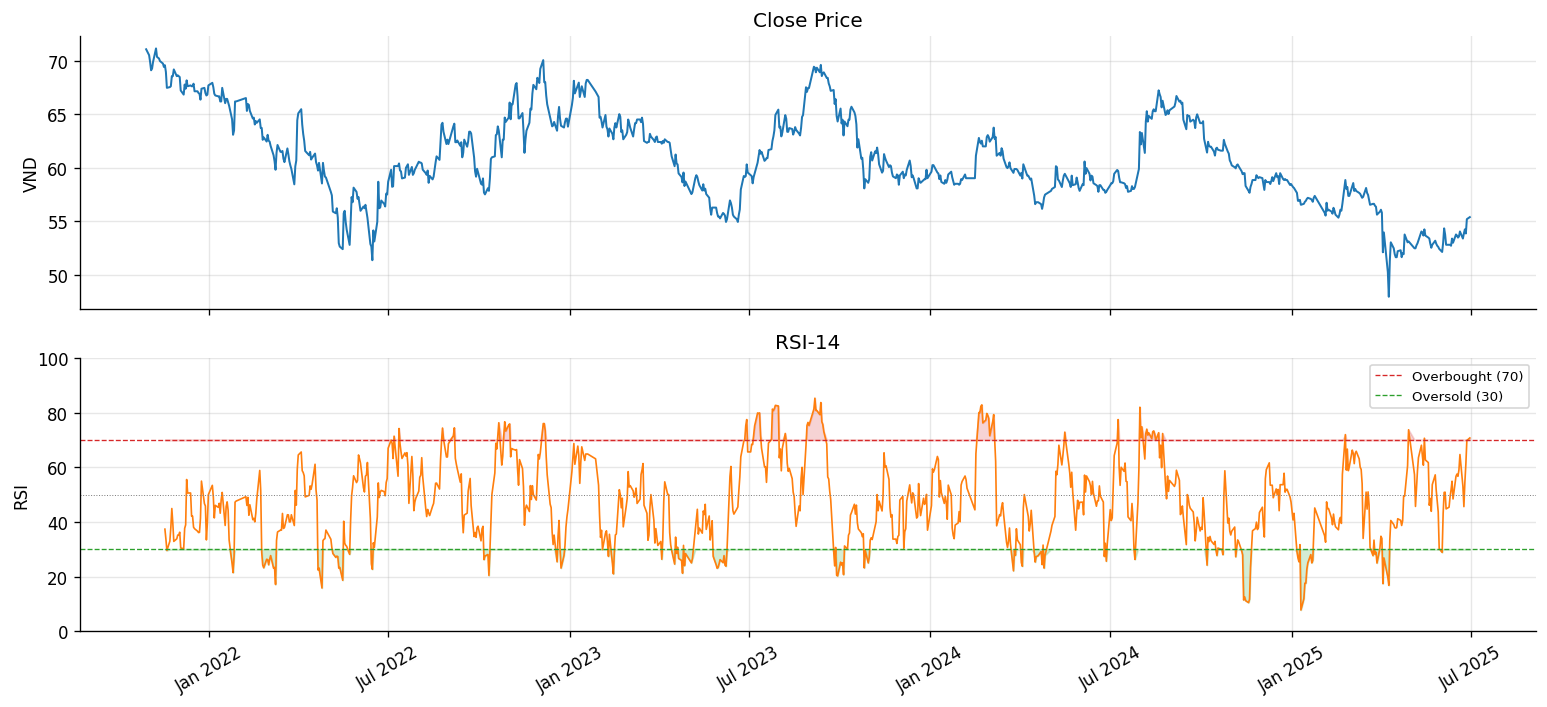

In [22]:
# ── RSI ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(df['date'], df['close'], color=BLUE, lw=1.2)
ax1.set_title('Close Price')
ax1.set_ylabel('VND')

ax2.plot(df['date'], df['rsi_14'], color=ORANGE, lw=1)
ax2.axhline(70, color=RED,   lw=0.8, ls='--', label='Overbought (70)')
ax2.axhline(30, color=GREEN, lw=0.8, ls='--', label='Oversold (30)')
ax2.axhline(50, color=GRAY,  lw=0.6, ls=':')
ax2.fill_between(df['date'], 70, df['rsi_14'].clip(lower=70), alpha=0.2, color=RED)
ax2.fill_between(df['date'], df['rsi_14'].clip(upper=30), 30, alpha=0.2, color=GREEN)
ax2.set_ylim(0, 100)
ax2.set_title('RSI-14')
ax2.set_ylabel('RSI')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

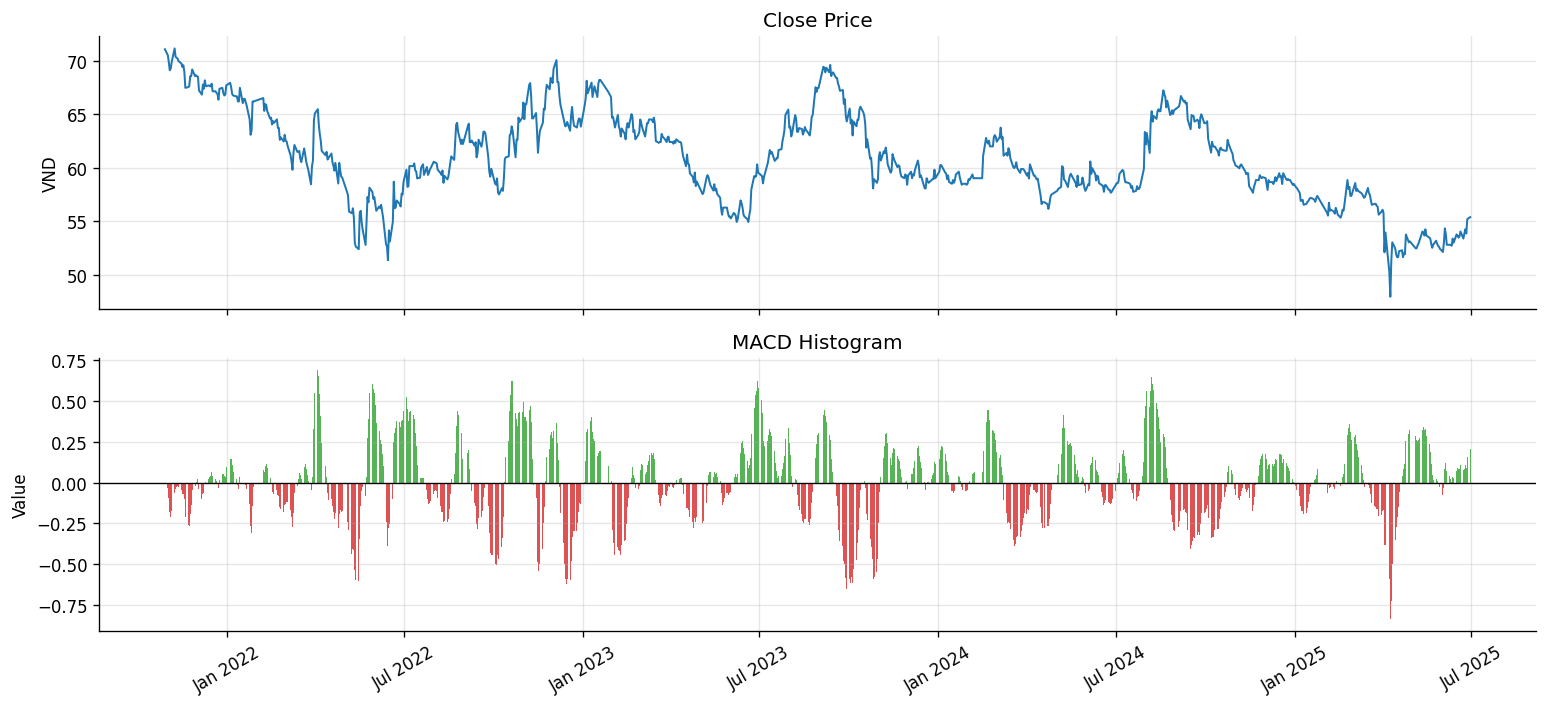

In [23]:
# ── MACD Histogram ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(df['date'], df['close'], color=BLUE, lw=1.2)
ax1.set_title('Close Price')
ax1.set_ylabel('VND')

macd = df['macd_histogram'].fillna(0)
colors = [GREEN if v >= 0 else RED for v in macd]
ax2.bar(df['date'], macd, color=colors, width=1, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('MACD Histogram')
ax2.set_ylabel('Value')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

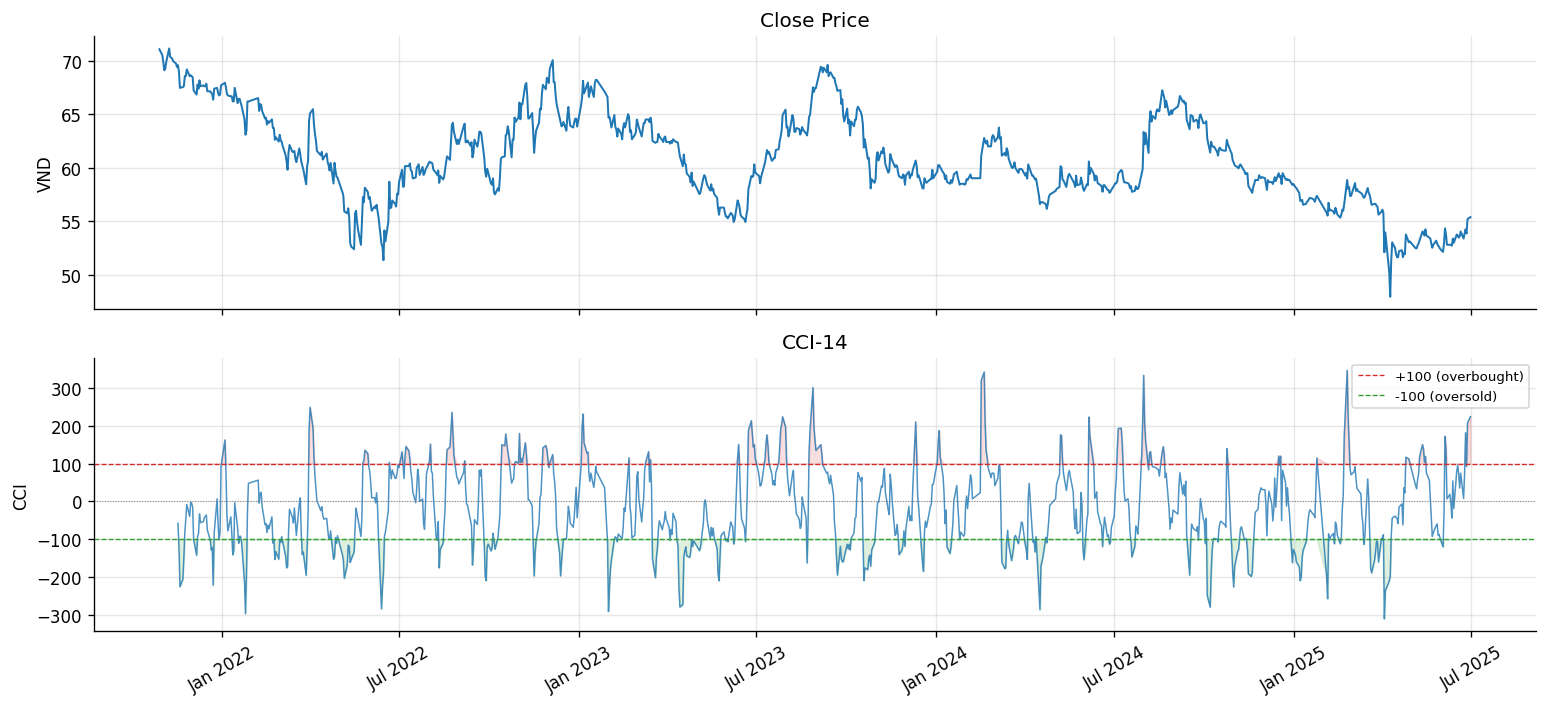

In [24]:
# ── CCI ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax1.plot(df['date'], df['close'], color=BLUE, lw=1.2)
ax1.set_title('Close Price')
ax1.set_ylabel('VND')

ax2.plot(df['date'], df['cci_14'], color=BLUE, lw=0.9, alpha=0.8)
ax2.axhline( 100, color=RED,   lw=0.8, ls='--', label='+100 (overbought)')
ax2.axhline(-100, color=GREEN, lw=0.8, ls='--', label='-100 (oversold)')
ax2.axhline(   0, color=GRAY,  lw=0.6, ls=':')
ax2.fill_between(df['date'],  100, df['cci_14'].clip(lower= 100), alpha=0.15, color=RED)
ax2.fill_between(df['date'], df['cci_14'].clip(upper=-100), -100, alpha=0.15, color=GREEN)
ax2.set_title('CCI-14')
ax2.set_ylabel('CCI')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

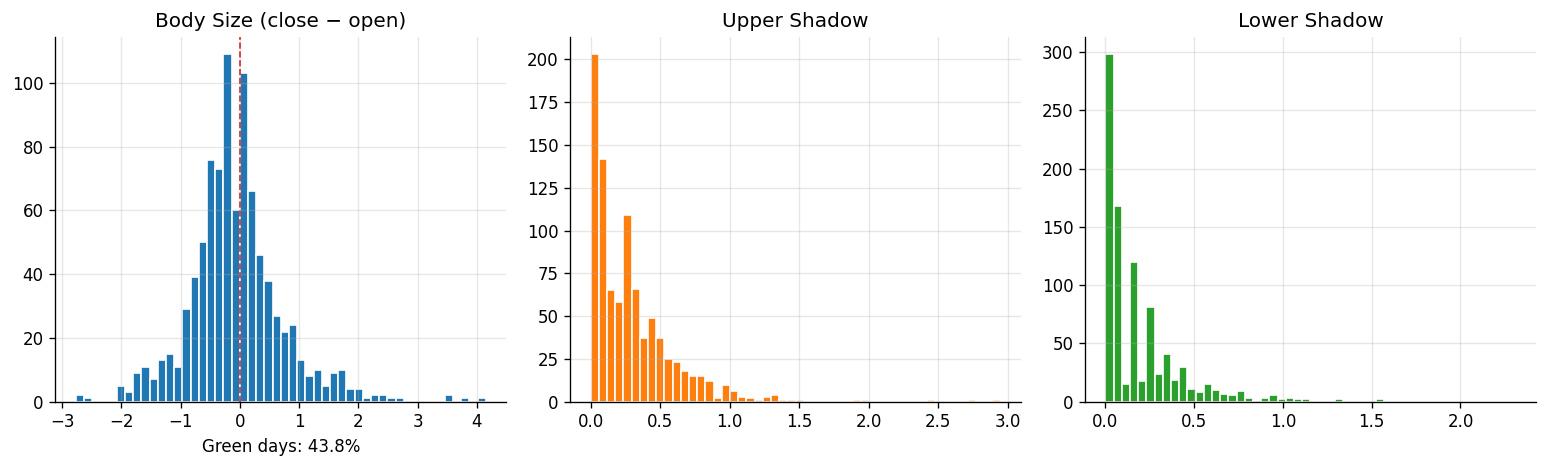

In [25]:
# ── Candlestick structure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].hist(df['body_size'].dropna(), bins=50, color=BLUE, edgecolor='white')
axes[0].axvline(0, color=RED, lw=1, ls='--')
axes[0].set_title('Body Size (close − open)')
pct_green = (df['body_size'] >= 0).mean() * 100
axes[0].set_xlabel(f'Green days: {pct_green:.1f}%')

axes[1].hist(df['upper_shadow'].dropna(), bins=50, color=ORANGE, edgecolor='white')
axes[1].set_title('Upper Shadow')

axes[2].hist(df['lower_shadow'].dropna(), bins=50, color=GREEN, edgecolor='white')
axes[2].set_title('Lower Shadow')

plt.tight_layout()
plt.show()

---
## 7. Market Context (VNM vs VN-Index)

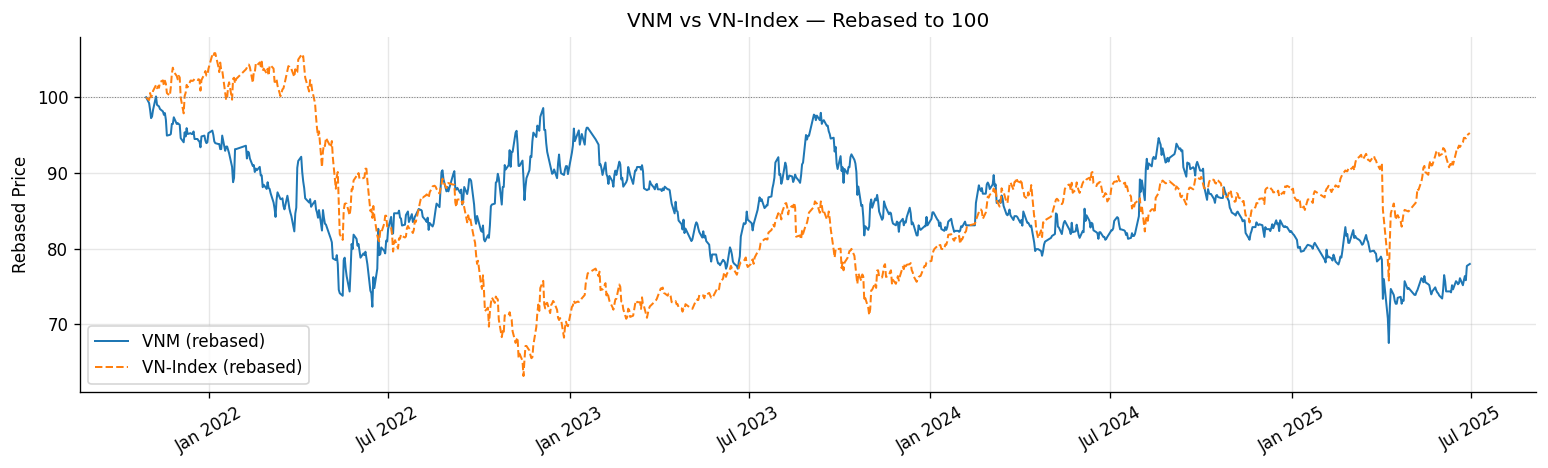

In [26]:
# ── VNM vs VN-Index (normalized to 100) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
vnm_norm   = df['close']   / df['close'].iloc[0]   * 100
vni_norm   = df['vnindex'] / df['vnindex'].iloc[0] * 100
ax.plot(df['date'], vnm_norm, color=BLUE,   lw=1.2, label='VNM (rebased)')
ax.plot(df['date'], vni_norm, color=ORANGE, lw=1.2, label='VN-Index (rebased)', ls='--')
ax.axhline(100, color=GRAY, lw=0.6, ls=':')
ax.set_title('VNM vs VN-Index — Rebased to 100')
ax.set_ylabel('Rebased Price')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

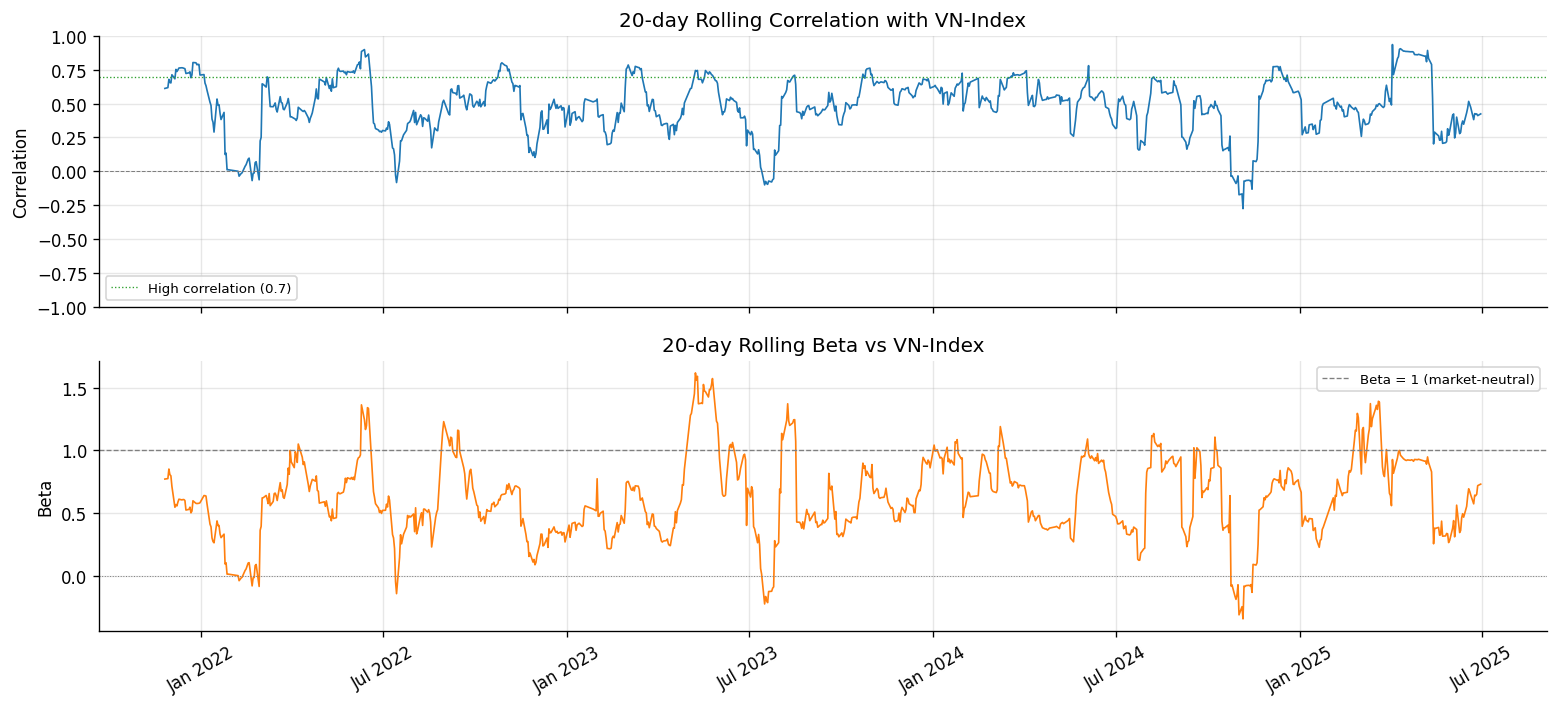

In [27]:
# ── Rolling correlation & beta ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df['date'], df['correlation_market_20'], color=BLUE, lw=1)
axes[0].axhline(0, color=GRAY, lw=0.6, ls='--')
axes[0].axhline(0.7, color=GREEN, lw=0.8, ls=':', label='High correlation (0.7)')
axes[0].set_ylim(-1, 1)
axes[0].set_title('20-day Rolling Correlation with VN-Index')
axes[0].set_ylabel('Correlation')
axes[0].legend(fontsize=8)

axes[1].plot(df['date'], df['beta_20'], color=ORANGE, lw=1)
axes[1].axhline(1.0, color=GRAY, lw=0.8, ls='--', label='Beta = 1 (market-neutral)')
axes[1].axhline(0,   color=GRAY, lw=0.6, ls=':')
axes[1].set_title('20-day Rolling Beta vs VN-Index')
axes[1].set_ylabel('Beta')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

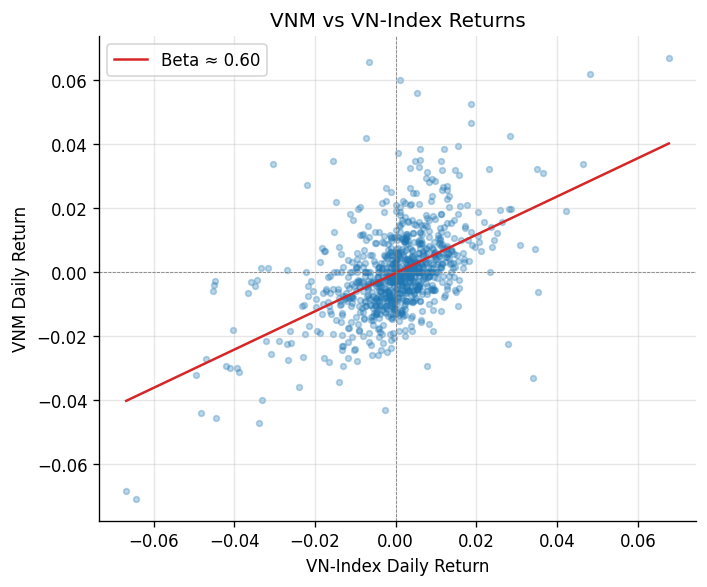

In [28]:
# ── VNM return vs VN-Index return scatter ──────────────────────────────────
scat = df[['log_return','vnindex_return']].dropna()
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scat['vnindex_return'], scat['log_return'],
           alpha=0.3, s=12, color=BLUE)
z = np.polyfit(scat['vnindex_return'], scat['log_return'], 1)
p = np.poly1d(z)
x_line = np.linspace(scat['vnindex_return'].min(), scat['vnindex_return'].max(), 100)
ax.plot(x_line, p(x_line), color=RED, lw=1.5, label=f'Beta ≈ {z[0]:.2f}')
ax.axhline(0, color=GRAY, lw=0.5, ls='--')
ax.axvline(0, color=GRAY, lw=0.5, ls='--')
ax.set_xlabel('VN-Index Daily Return')
ax.set_ylabel('VNM Daily Return')
ax.set_title('VNM vs VN-Index Returns')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Calendar Effects

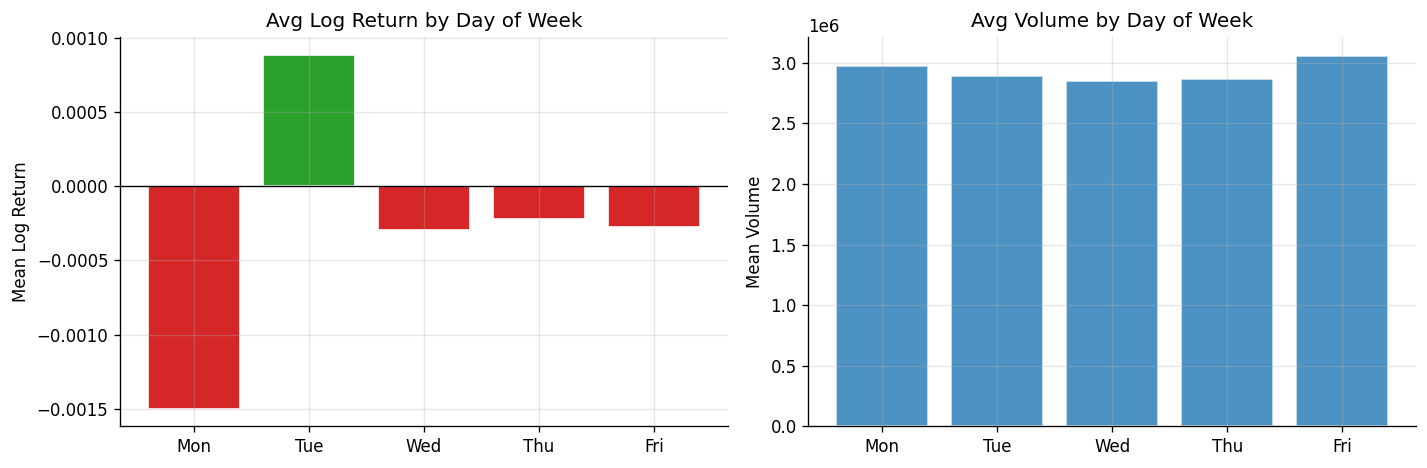

             mean     std  count
dow_label                       
Fri       -0.0003  0.0118    184
Mon       -0.0015  0.0140    178
Thu       -0.0002  0.0152    184
Tue        0.0009  0.0149    183
Wed       -0.0003  0.0128    183


In [29]:
# ── Day-of-week effects ────────────────────────────────────────────────────
dow_labels = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
df['dow_label'] = df['day_of_week'].map(dow_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean return by day
ret_by_dow = df.groupby('day_of_week')['log_return'].mean()
colors_dow = [GREEN if v >= 0 else RED for v in ret_by_dow]
axes[0].bar([dow_labels[d] for d in ret_by_dow.index], ret_by_dow.values,
            color=colors_dow, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Avg Log Return by Day of Week')
axes[0].set_ylabel('Mean Log Return')

# Mean volume by day
vol_by_dow = df.groupby('day_of_week')['volume'].mean()
axes[1].bar([dow_labels[d] for d in vol_by_dow.index], vol_by_dow.values,
            color=BLUE, edgecolor='white', alpha=0.8)
axes[1].set_title('Avg Volume by Day of Week')
axes[1].set_ylabel('Mean Volume')

plt.tight_layout()
plt.show()

print(df.groupby('dow_label')['log_return'].agg(['mean','std','count']).round(4))

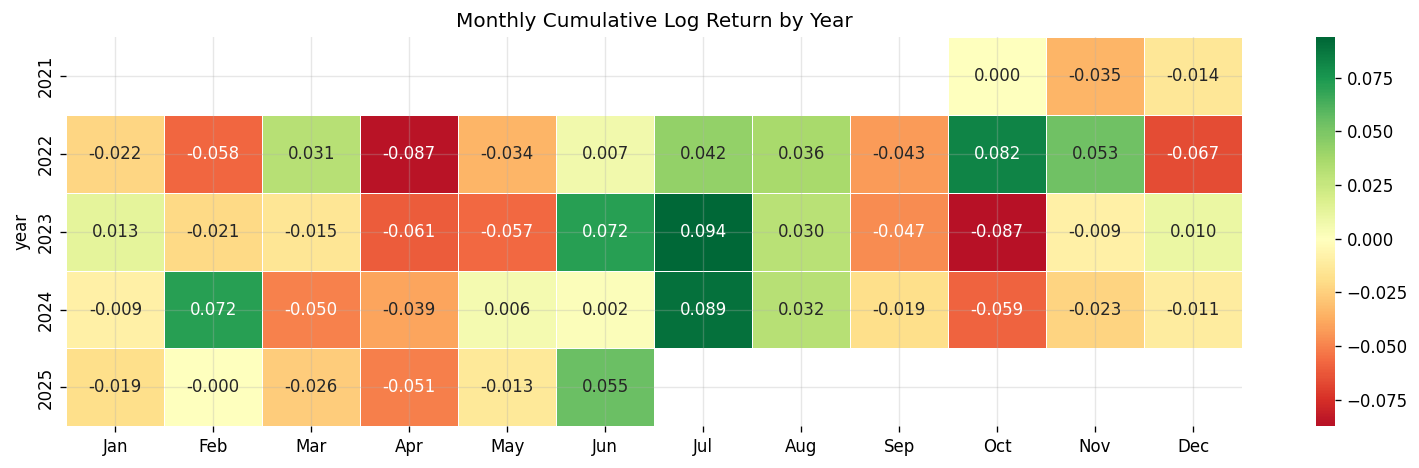

In [30]:
# ── Monthly return heatmap ─────────────────────────────────────────────────
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

monthly_ret = df.groupby(['year','month'])['log_return'].sum().unstack()
monthly_ret.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                       'Jul','Aug','Sep','Oct','Nov','Dec'][:len(monthly_ret.columns)]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(monthly_ret, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Monthly Cumulative Log Return by Year')
plt.tight_layout()
plt.show()